LINEAR FIT RESULTS
slope     m = -1.0717 ± 0.0598
intercept b = -0.066008 ± 0.006681
f_D         = -15.1497 ± 1.5333
Plotted line: Y = (-1.0717) X + (-0.066008)


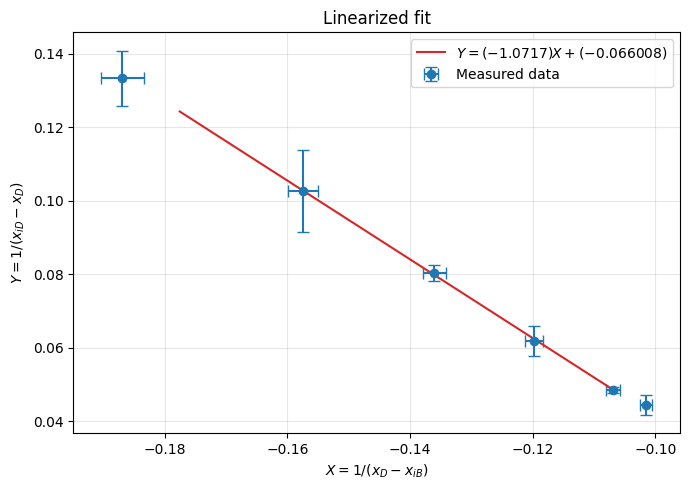

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_B  = 60.0
x_iB = 83.35

x_D = np.array([78.0, 77.0, 76.0, 75.0, 74.0, 73.5])

x_iD_min = np.array([85.2, 86.0, 88.2, 90.4, 94.4, 95.0])
x_iD_max = np.array([85.8, 87.5, 88.7, 91.9, 94.9, 97.0])

x_iD        = (x_iD_min + x_iD_max) / 2.0
sigma_x_iD  = (x_iD_max - x_iD_min) / 2.0

sigma_x_iB = 0.1

u = x_D - x_iB
v = x_iD - x_D

X = 1.0 / u
Y = 1.0 / v

sigma_X = sigma_x_iB / (u**2)
sigma_Y = np.sqrt((sigma_x_iD / (v**2))**2 + (sigma_x_iD / (v**2))**2)

weights = 1.0 / sigma_Y**2

W   = np.sum(weights)
WX  = np.sum(weights * X)
WY  = np.sum(weights * Y)
WXX = np.sum(weights * X * X)
WXY = np.sum(weights * X * Y)

Delta = W * WXX - WX**2

slope     = (W * WXY - WX * WY) / Delta
intercept = (WXX * WY - WX * WXY) / Delta

sigma_slope     = np.sqrt(W   / Delta)
sigma_intercept = np.sqrt(WXX / Delta)

f_D       = 1.0 / intercept
sigma_f_D = sigma_intercept / intercept**2

print("=" * 60)
print("LINEAR FIT RESULTS")
print("=" * 60)
print(f"slope     m = {slope:.4f} ± {sigma_slope:.4f}")
print(f"intercept b = {intercept:.6f} ± {sigma_intercept:.6f}")
print(f"f_D         = {f_D:.4f} ± {sigma_f_D:.4f}")
print("=" * 60)
print(f"Plotted line: Y = ({slope:.4f}) X + ({intercept:.6f})")

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(X, Y, xerr=sigma_X, yerr=sigma_Y, fmt='o', capsize=4,
            color='tab:blue', label='Measured data')

X_line = np.linspace(X.min() * 0.95, X.max() * 1.05, 100)
Y_line = slope * X_line + intercept
ax.plot(X_line, Y_line, '-', color='tab:red',
        label=f'$Y = ({slope:.4f})X + ({intercept:.6f})$')

ax.set_xlabel('$X = 1/(x_D - x_{iB})$')
ax.set_ylabel('$Y = 1/(x_{iD} - x_D)$')
ax.set_title('Linearized fit')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('focal_length_fit.png', dpi=150)
plt.show()

In [3]:
import numpy as np

x_o = 13.5

x_E_min = np.array([52.5, 52.3, 52.6, 52.5, 52.5, 52.8])
x_E_max = np.array([53.0, 53.2, 53.2, 53.3, 53.4, 53.4])

x_E       = (x_E_min + x_E_max) / 2.0
sigma_x_E = (x_E_max - x_E_min) / 2.0

sigma_x_o = 0.1

d         = np.abs(x_o - x_E)
sigma_d   = np.sqrt(sigma_x_o**2 + sigma_x_E**2)

f_E       = d / 2.0
sigma_f_E = sigma_d / 2.0

for i in range(len(x_E)):
    print(f"x_E = {x_E[i]:.3f} ± {sigma_x_E[i]:.3f}  ->  "
          f"d = {d[i]:.3f} ± {sigma_d[i]:.3f}  ->  "
          f"f_E = {f_E[i]:.3f} ± {sigma_f_E[i]:.3f}")

f_E_mean       = np.mean(f_E)
sigma_f_E_mean = np.sqrt(np.sum(sigma_f_E**2)) / len(f_E)

print("=" * 60)
print(f"Mean f_E = {f_E_mean:.4f} ± {sigma_f_E_mean:.4f}")
print("=" * 60)

x_E = 52.750 ± 0.250  ->  d = 39.250 ± 0.269  ->  f_E = 19.625 ± 0.135
x_E = 52.750 ± 0.450  ->  d = 39.250 ± 0.461  ->  f_E = 19.625 ± 0.230
x_E = 52.900 ± 0.300  ->  d = 39.400 ± 0.316  ->  f_E = 19.700 ± 0.158
x_E = 52.900 ± 0.400  ->  d = 39.400 ± 0.412  ->  f_E = 19.700 ± 0.206
x_E = 52.950 ± 0.450  ->  d = 39.450 ± 0.461  ->  f_E = 19.725 ± 0.230
x_E = 53.100 ± 0.300  ->  d = 39.600 ± 0.316  ->  f_E = 19.800 ± 0.158
Mean f_E = 19.6958 ± 0.0776


LINEAR FIT THROUGH ORIGIN
w_o       = 0.9447 ± 0.0029
A         = 7.7242 ± 0.2381
M         = 8.1767 ± 0.2533
chi^2     = 58.8256
dof       = 5
chi^2/dof = 11.7651

PER-TRIAL VALUES
x_B = 45.60  x_C = 84.40  s = 11.013  M = 4.6908 ± 0.5865
x_B = 42.40  x_C = 84.00  s = 13.813  M = 9.6114 ± 0.5661
x_B = 45.00  x_C = 83.70  s = 10.913  M = 8.2569 ± 0.5510
x_B = 41.30  x_C = 84.80  s = 15.713  M = 10.3476 ± 0.6095
x_B = 39.40  x_C = 89.00  s = 21.813  M = 9.7466 ± 0.9751
x_B = 47.30  x_C = 84.90  s = 9.813  M = 7.3739 ± 0.6149


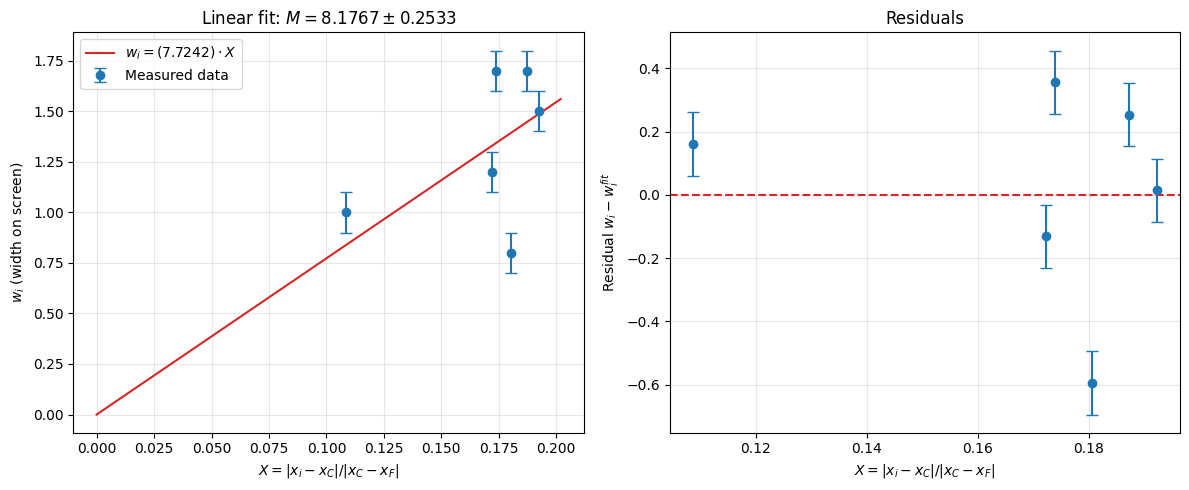

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x_F = 13.5
x_i = 97.2

w_o_values = np.array([0.944, 0.950, 0.940])
w_o = np.mean(w_o_values)
sigma_w_o = np.std(w_o_values, ddof=1) / np.sqrt(len(w_o_values))

f_B = 21.77
sigma_f_B = 0.04

f_C = 6.017
sigma_f_C = 0.017

x_B = np.array([45.6, 42.4, 45.0, 41.3, 39.4, 47.3])

x_C = np.array([84.4, 84.0, 83.7, 84.8, 89.0, 84.9])
w_i = np.array([0.8, 1.7, 1.5, 1.7, 1.0, 1.2])
sigma_w_i = np.array([0.1 for _ in range(6)])

s = (x_C - x_B) - (f_B + f_C)

X = np.abs(x_i - x_C) / np.abs(x_C - x_F)
Y = w_i

def model(X, A):
    return A * X

popt, pcov = curve_fit(model, X, Y, p0=[15.0], sigma=sigma_w_i, absolute_sigma=True)

A = popt[0]
sigma_A = np.sqrt(np.diag(pcov))[0]

M = A / w_o
sigma_M = M * np.sqrt((sigma_A / A)**2 + (sigma_w_o / w_o)**2)

M_trials = (w_i / w_o) * (np.abs(x_C - x_F) / np.abs(x_i - x_C))
sigma_M_trials = M_trials * np.sqrt((sigma_w_i / w_i)**2 + (sigma_w_o / w_o)**2)

residuals = Y - model(X, *popt)
dof = len(X) - len(popt)
chi2 = np.sum((residuals / sigma_w_i) ** 2)
chi2_red = chi2 / dof

print("=" * 60)
print("LINEAR FIT THROUGH ORIGIN")
print("=" * 60)
print(f"w_o       = {w_o:.4f} ± {sigma_w_o:.4f}")
print(f"A         = {A:.4f} ± {sigma_A:.4f}")
print(f"M         = {M:.4f} ± {sigma_M:.4f}")
print(f"chi^2     = {chi2:.4f}")
print(f"dof       = {dof}")
print(f"chi^2/dof = {chi2_red:.4f}")
print("=" * 60)

print("\nPER-TRIAL VALUES")
print("=" * 60)
for i in range(len(x_C)):
    print(f"x_B = {x_B[i]:.2f}  x_C = {x_C[i]:.2f}  "
          f"s = {s[i]:.3f}  M = {M_trials[i]:.4f} ± {sigma_M_trials[i]:.4f}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.errorbar(X, Y, yerr=sigma_w_i, fmt='o', capsize=4,
            color='tab:blue', label='Measured data')

X_line = np.linspace(0, X.max() * 1.05, 100)
ax.plot(X_line, model(X_line, *popt), '-', color='tab:red',
        label=f'$w_i = ({A:.4f}) \\cdot X$')

ax.set_xlabel('$X = |x_i - x_C| / |x_C - x_F|$')
ax.set_ylabel('$w_i$ (width on screen)')
ax.set_title(f'Linear fit: $M = {M:.4f} \\pm {sigma_M:.4f}$')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.errorbar(X, residuals, yerr=sigma_w_i, fmt='o', capsize=4,
            color='tab:blue')
ax.axhline(0, color='tab:red', linestyle='--')
ax.set_xlabel('$X = |x_i - x_C| / |x_C - x_F|$')
ax.set_ylabel('Residual $w_i - w_i^{fit}$')
ax.set_title('Residuals')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('magnification_fit.png', dpi=150)
plt.show()

M vs s*(x_i - x_C)
trial 1  s = 11.013  x_i-x_C = 12.80  s*(x_i-x_C) = 140.966  M = 4.6908 ± 0.5865
trial 2  s = 13.813  x_i-x_C = 13.20  s*(x_i-x_C) = 182.332  M = 9.6114 ± 0.5661
trial 3  s = 10.913  x_i-x_C = 13.50  s*(x_i-x_C) = 147.326  M = 8.2569 ± 0.5510
trial 4  s = 15.713  x_i-x_C = 12.40  s*(x_i-x_C) = 194.841  M = 10.3476 ± 0.6095
trial 5  s = 21.813  x_i-x_C = 8.20  s*(x_i-x_C) = 178.867  M = 9.7466 ± 0.9751
trial 6  s = 9.813  x_i-x_C = 12.30  s*(x_i-x_C) = 120.700  M = 7.3739 ± 0.6149

LINEAR FIT: M = m*[s*(x_i-x_C)] + b
slope     m = 0.056031 ± 0.009603
intercept b = -0.7264 ± 1.5463
chi^2       = 24.7006
dof         = 4
chi^2/dof   = 6.1752


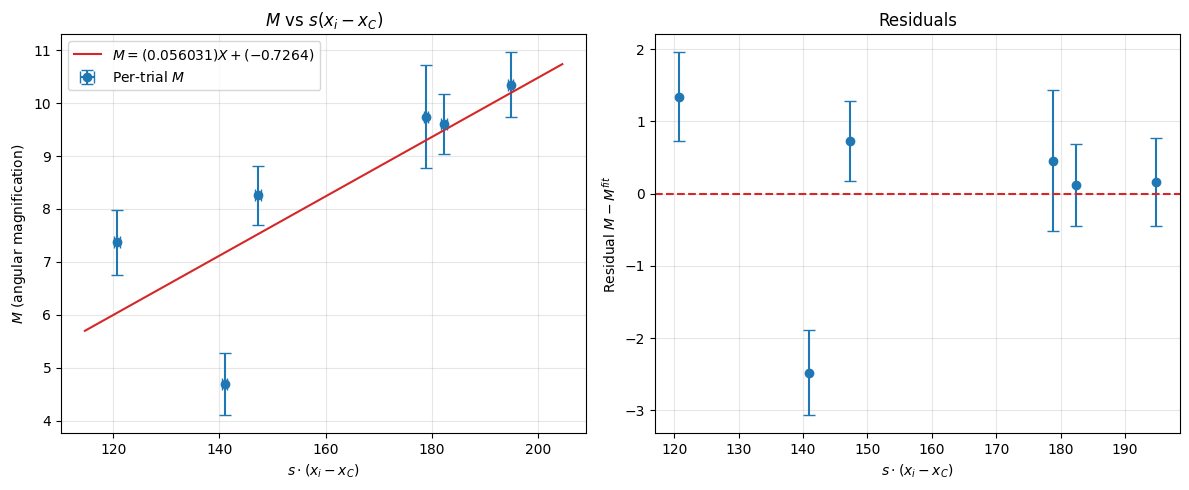

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x_F = 13.5
x_i = 97.2

w_o_values = np.array([0.944, 0.950, 0.940])
w_o = np.mean(w_o_values)
sigma_w_o = np.std(w_o_values, ddof=1) / np.sqrt(len(w_o_values))

f_B = 21.77
sigma_f_B = 0.04

f_C = 6.017
sigma_f_C = 0.017

x_B = np.array([45.6, 42.4, 45.0, 41.3, 39.4, 47.3])

x_C = np.array([84.4, 84.0, 83.7, 84.8, 89.0, 84.9])
w_i = np.array([0.8, 1.7, 1.5, 1.7, 1.0, 1.2])
sigma_w_i = np.array([0.1 for _ in range(6)])

s = (x_C - x_B) - (f_B + f_C)

M_trials = (w_i / w_o) * (np.abs(x_C - x_F) / np.abs(x_i - x_C))
sigma_M_trials = M_trials * np.sqrt((sigma_w_i / w_i)**2 + (sigma_w_o / w_o)**2)

X_plot = s * (x_i - x_C)

sigma_X_plot = np.abs(x_i - x_C) * np.sqrt(sigma_f_B**2 + sigma_f_C**2)

print("=" * 60)
print("M vs s*(x_i - x_C)")
print("=" * 60)
for i in range(len(x_C)):
    print(f"trial {i+1}  s = {s[i]:.3f}  x_i-x_C = {x_i-x_C[i]:.2f}  "
          f"s*(x_i-x_C) = {X_plot[i]:.3f}  M = {M_trials[i]:.4f} ± {sigma_M_trials[i]:.4f}")
print("=" * 60)

def linear(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear, X_plot, M_trials, p0=[0.01, 0.0],
                       sigma=sigma_M_trials, absolute_sigma=True)

m = popt[0]
b = popt[1]
sigma_m = np.sqrt(np.diag(pcov))[0]
sigma_b = np.sqrt(np.diag(pcov))[1]

residuals = M_trials - linear(X_plot, *popt)
dof = len(X_plot) - len(popt)
chi2 = np.sum((residuals / sigma_M_trials) ** 2)
chi2_red = chi2 / dof

print("\nLINEAR FIT: M = m*[s*(x_i-x_C)] + b")
print("=" * 60)
print(f"slope     m = {m:.6f} ± {sigma_m:.6f}")
print(f"intercept b = {b:.4f} ± {sigma_b:.4f}")
print(f"chi^2       = {chi2:.4f}")
print(f"dof         = {dof}")
print(f"chi^2/dof   = {chi2_red:.4f}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.errorbar(X_plot, M_trials, yerr=sigma_M_trials, xerr=sigma_X_plot,
            fmt='o', capsize=4, color='tab:blue', label='Per-trial $M$')

X_line = np.linspace(X_plot.min() * 0.95, X_plot.max() * 1.05, 100)
ax.plot(X_line, linear(X_line, *popt), '-', color='tab:red',
        label=f'$M = ({m:.6f})X + ({b:.4f})$')

ax.set_xlabel('$s \\cdot (x_i - x_C)$')
ax.set_ylabel('$M$ (angular magnification)')
ax.set_title('$M$ vs $s(x_i - x_C)$')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.errorbar(X_plot, residuals, yerr=sigma_M_trials, fmt='o', capsize=4,
            color='tab:blue')
ax.axhline(0, color='tab:red', linestyle='--')
ax.set_xlabel('$s \\cdot (x_i - x_C)$')
ax.set_ylabel('Residual $M - M^{fit}$')
ax.set_title('Residuals')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('M_vs_s_xi_xC.png', dpi=150)
plt.show()